<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 5: АБ-тест
</center>

**ФИО:** Гаврин Глеб Юрьевич

## Общая информация

__Дата выдачи:__ 07.04.2025

__Дедлайн:__ 23:59MSK 20.04.2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import seaborn as sns
from tqdm import tqdm
import pandas as pd


На семинаре мы попытались разобраться как устроена процедура АБ-тестирования. В этом задании мы попытаемся закрепить полученные знания и более аккуратно структурировать их.

### Кратко повторим теорию

Мы хотим выктить новую функциональность на сайте. Перед раскаткой нам хочется проверить, какой эффект мы оказываем на пользователя. Выделим две выборки: тестовую (treatment) и контрольную (control). Тестовой покажем новый сайт. Контрольной старый. Замерим инетерсующую нас метрику, нааример, время проведенной на сайте, в обеих группах:

$$
\begin{aligned}
&X^c_1, \ldots, X^c_{n_c} \sim iid (\mu_c, \sigma^2_c) \\
&X^t_1, \ldots, X^t_{n_t} \sim iid (\mu_t, \sigma^2_t)
\end{aligned}
$$

У выборок есть какие-то математические ожидания, дисперсии. Выборки собраны независимо друг от друга. Если их математические ожидания одинаковые, будем считать, что новая функциональность никак не повлияла на пользователей. Сформулируем это в виде нашей нулевой гипотезы:

$$
\begin{aligned}
&H_0: \hspace{2mm} \mu_c = \mu_t \\
&H_1: \hspace{2mm} \mu_c < \mu_t.
\end{aligned}
$$

Посчитаем по выборке расстояние между математическими ожиданиями $\hat \mu_t - \hat \mu_c$. Оно по ЦПТ имеет нормальное распределение с оценкой дисперсии $\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}$. Получается, что

$$
z = \frac{\hat \mu_t - \hat \mu_c}{\sqrt{\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}}} \sim N(0,1),
$$

при верности нулевой гипотезы и $n \to \infty$. Если это расстояние оказывается слишком большим, мы отказываемся верить в нулевую гипотезу. Эффект от новой функциональности есть. Будем сравнивать наблюдаемое значение $z$ с $z_{1 - \alpha},$ где уровень значимости $\alpha$ выберем до начала эксперимента.

- Если $z < z_{1 - \alpha},$ нулевая гипотеза не отвергается (похоже, что верна). Расстояние маленькое, разницы нет.
- Если $z > z_{1 - \alpha},$ выбираем альтернативу. У на есть значимый эффект на метрику, от веры в нулевую гипотезу придётся отказаться.

> Ничего не понятно? Тогда вам в лекции. Ниже подборка:  

- [Наша лекция про АБ]( )
- [Неделя про проверку гипотез с курсеры](https://www.youtube.com/watch?v=Zv-5gbJtofk&list=PLCf-cQCe1FRxTgNPwcRSkBjvtE8DEm7rU)


## Задания


__а) [1 балл]__ Реализуйте функцию для проверки гипотезы о равенстве математических ожиданий. Она должна принимать на вход две выборки и выдавать на выход наблюдаемое значение статистики `z_obs` и `p_value` для ситуаций с разными альтернативными гипотезами.

In [2]:
def asy_mean_test(x_control, x_treatment, alternative = 'larger'):
    if alternative == 'two-sided':
        z_obs = (np.mean(x_treatment) - np.mean(x_control)) / np.sqrt((np.var(x_treatment)/np.size(x_treatment)) + (np.var(x_control)/np.size(x_control)))
        p_value = 2 * (1 - stats.norm.cdf(abs(z_obs)))
        
    elif alternative == 'larger':
        z_obs = (np.mean(x_treatment) - np.mean(x_control)) / np.sqrt((np.var(x_treatment)/np.size(x_treatment)) + (np.var(x_control)/np.size(x_control)))
        p_value = 1 - stats.norm.cdf(z_obs)
    elif alternative == 'less':
         z_obs = (np.mean(x_treatment) - np.mean(x_control)) / np.sqrt((np.var(x_treatment)/np.size(x_treatment)) + (np.var(x_control)/np.size(x_control)))
         p_value = stats.norm.cdf(z_obs)
    
          



    return z_obs, p_value

Если вы написали весь код выше корректно, то строки ниже сработают без проблем.

In [3]:
def gen_sample(n_obs, effect, p_control):
    p_treatment = p_control * (1 + effect)
    x_control = stats.bernoulli(p_control).rvs(n_obs)
    x_treatment = stats.bernoulli(p_treatment).rvs(n_obs)
    return x_control, x_treatment

In [4]:
# Проверка ситуации, когда верна нулевая гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0, 0.2))
assert pval > 0.01

In [5]:
# Проверка ситуации, когда верна альтернативная гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0.1, 0.2))
assert pval < 0.01

Для простоты мы дальше будем работать с односторонней альтернативой и тестом для долей.

$$
\begin{aligned}
&H_0: \hspace{2mm} p_t = p_c \\
&H_1: \hspace{2mm} p_t > p_c
\end{aligned}
$$

__б) [2 балла]__ Предположим, что нулевая гипотеза верна. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы.

При верности нулевой гипотезы все значения pvalue равновероятны => оно распределено **равномерно на отрезке [0, 1]**.\
Z_obs при верности нулевой гипотезы распределена **стандартно нормально**

In [6]:
asy_mean_test(*gen_sample(10**5, 0.1, 0.2))

(11.176739248943576, 0.0)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:10<00:00, 965.99it/s]


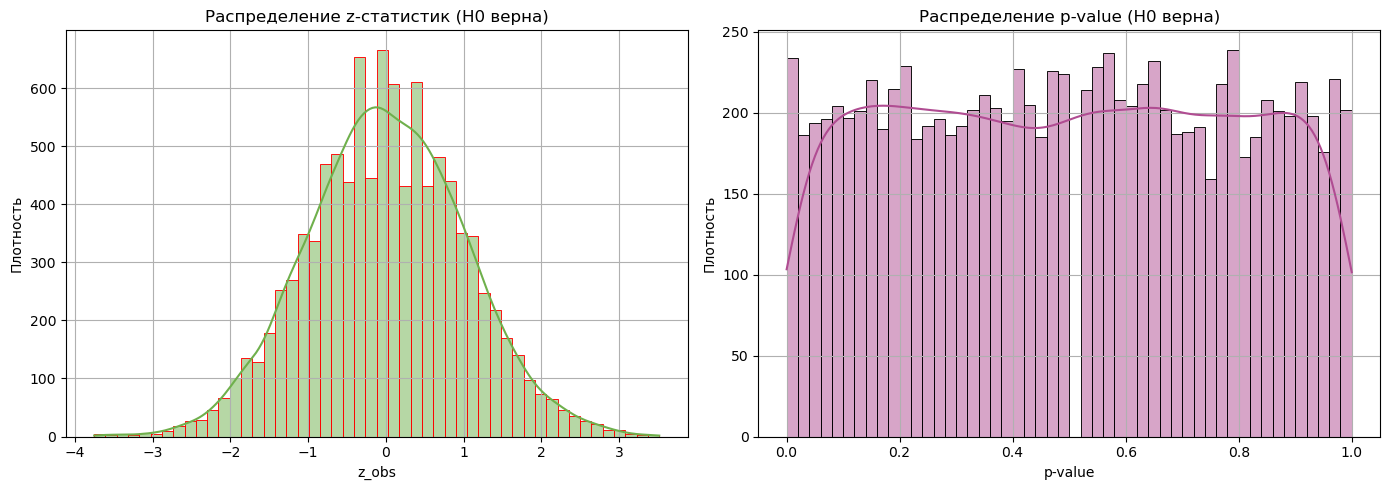

In [7]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0 # при верности Н0 мат ожидания равны

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t)
    z_values.append(z)
    p_values.append(p)


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(z_values, bins=50, kde=True, color="#6FB04C", edgecolor='red')
plt.title("Распределение z-статистик (H0 верна)")
plt.xlabel("z_obs")
plt.ylabel("Плотность")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(p_values, bins=50, kde=True, color="#B04C92", edgecolor='black')
plt.title("Распределение p-value (H0 верна)")
plt.xlabel("p-value")
plt.ylabel("Плотность")
plt.grid(True)

plt.tight_layout()
plt.show()

Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

In [8]:
np.mean(z_values)

0.003927169769494789

__Ответ:__  распределение pvalue оказалось равномерным на [0, 1], так и должно быть при верности нулевой гипотезы.\
У распределения z_obs мат ожидание ~= 0. Так происходит потому, что вероятность того, что значение z_obs превысит определённый порог является одинаковой для всех значений от 0 до 1. То есть, чем больше итераций мы делаем, тем более равномерным становится распределение p-value по интервалу от 0 до 1.

__в) [1 балл]__ Предположим, что верна альтернативная гипотеза. Доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы и прокомментируйте получившиеся результаты.

100%|██████████| 10000/10000 [00:14<00:00, 674.53it/s]


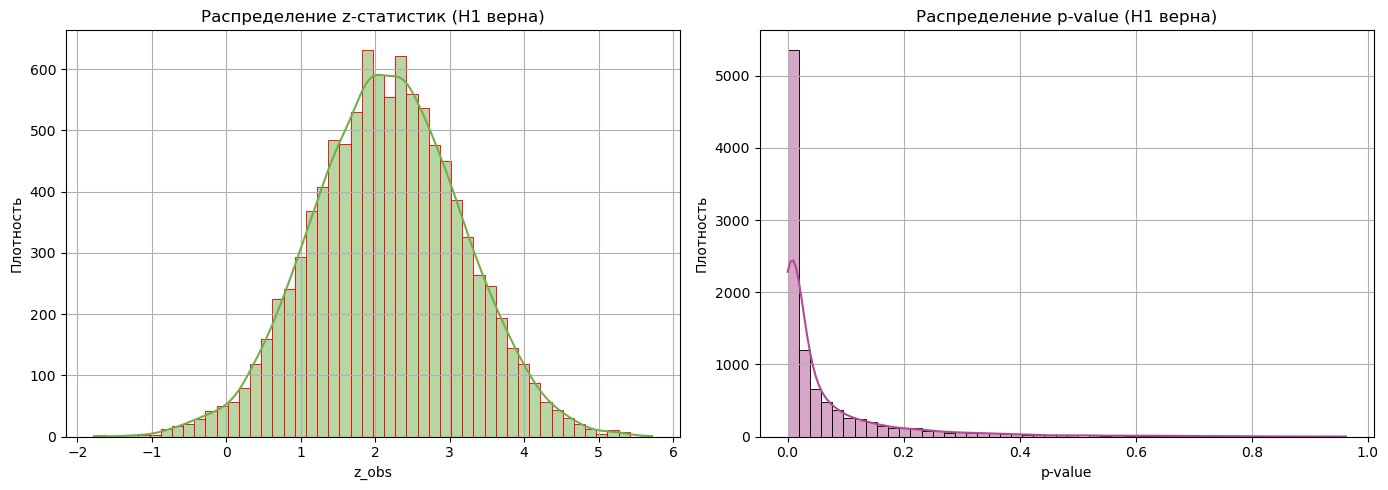

In [9]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.2 # при верности Н1 мат ожидание в тестовой группе больше

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t)
    z_values.append(z)
    p_values.append(p)


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(z_values, bins=50, kde=True, color="#6FB04C", edgecolor='red')
plt.title("Распределение z-статистик (H1 верна)")
plt.xlabel("z_obs")
plt.ylabel("Плотность")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(p_values, bins=50, kde=True, color="#B04C92", edgecolor='black')
plt.title("Распределение p-value (H1 верна)")
plt.xlabel("p-value")
plt.ylabel("Плотность")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
round(np.mean(z_values), 4)

2.1639

При большом количестве наблюдений мат ожидание Z_obs сдвигается вправо от нуля. Математическое ожидание z_obs будет больше 0, поскольку среднее значение в тестовой группе больше, чем в контрольной. Чем больше эффект, тем больше смещение распределения p-value влево и тем больше математическое ожидание z_obs. pvalue теперь распределен неравномерно, большая часть значений сосредоточена около нуля, что ожидаемо при наличии эффекта > 0

А как будут выглядеть результаты, если доля в тестовой выборке больше на $40\%$? Проведите симуляции.

100%|██████████| 10000/10000 [00:14<00:00, 667.74it/s]


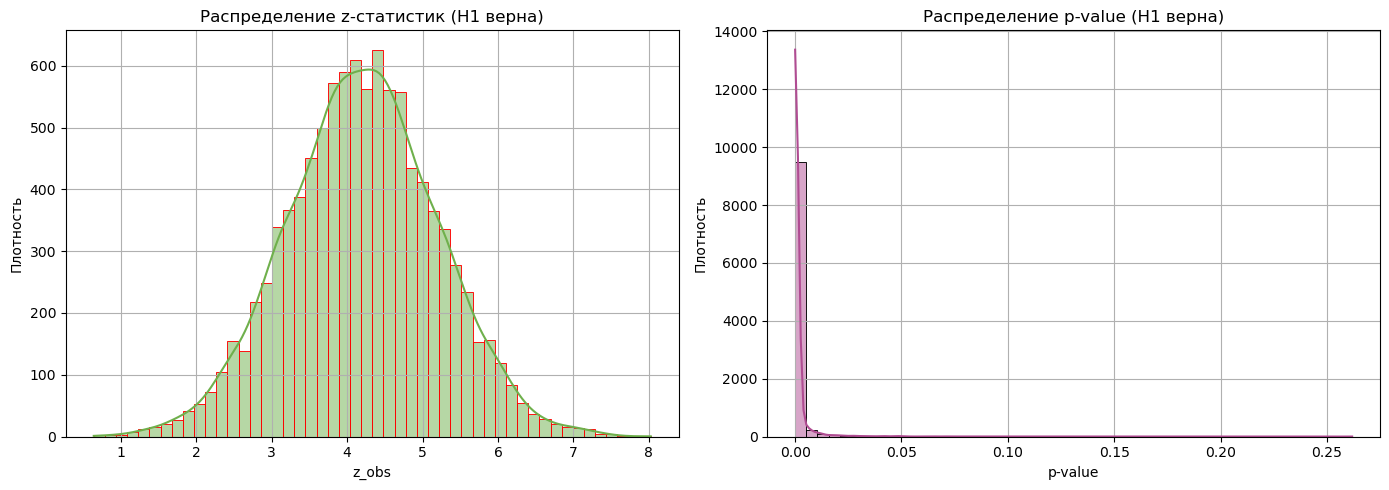

In [11]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.4 # при верности Н1 мат ожидание в тестовой группе больше

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t)
    z_values.append(z)
    p_values.append(p)


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(z_values, bins=50, kde=True, color="#6FB04C", edgecolor='red')
plt.title("Распределение z-статистик (H1 верна)")
plt.xlabel("z_obs")
plt.ylabel("Плотность")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(p_values, bins=50, kde=True, color="#B04C92", edgecolor='black')
plt.title("Распределение p-value (H1 верна)")
plt.xlabel("p-value")
plt.ylabel("Плотность")
plt.grid(True)

plt.tight_layout()
plt.show()

Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

__Ответ:__ Ожидаемо, при росте эффекта распределение z_obs сдвинулось еще правее, а распределение p-value еще сильнее прижалось к 0

__г) [1 балл]__ Обычно, перед началом эксперимента, мы фиксируем ошибку первого рода, вероятность отвергнуть нулевую гипотезу, когда она на самом деле верна,  

$$\alpha = \mathbb{P}(H_A \text{ выбрана} \mid H_0 \text{ верна}).$$

Дальше мы принимаем решение, о том, какую гипотезу выбрать, сравнивая `z_obs` с $z_{1 - \alpha},$ либо `pvalue` с $\alpha$ (напомню что мы делаем симуляции для правосторонней альтернативы, поэтому $\alpha$ не надо делить на два).

Давайте проверим для конкретного $\alpha$, что это правда работает. Выберите любое разумное значение $\alpha$. С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$ при верности нулевой гипотезы. Проверьте эти гипотезы и оцените получившееся значение $\alpha$. Правда ли, что оно оказалось равно заявленному значению?

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [12]:
# я выберу alpha = 0.05
alpha = 0.05

In [13]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0 # при верности Н0 мат ожидание в тестовой группе равно мат ожмданию в контрольной группе

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t, alternative='larger')
    z_values.append(z)
    p_values.append(p)


# мы отвергаем нулевую гипотезу, если p-value < alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
p_values_h1 = [pvalue for pvalue in p_values if pvalue < alpha]
alpha_observed = round(len(p_values_h1)/len(p_values), 2)
print(f'Получившееся alpha = {alpha_observed}')

100%|██████████| 10000/10000 [00:14<00:00, 682.57it/s]

Получившееся alpha = 0.05


**Получившееся alpha совпадает с теоретическим!**

Кроме ошибки первого рода есть ещё и ошибка второго рода, вероятность остаться с нулевой гипотезой, когда верна альтернатива,

$$\beta = \mathbb{P}(H_0 \text{ выбрана} \mid H_A \text{ верна}).$$

Давайте предположим, что доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. С помощью симуляций того же самого объёма оцените, чему равна $\beta$.

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [14]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.2 # эффект 20%

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t, alternative='larger')
    z_values.append(z)
    p_values.append(p)


# мы не отвергаем нулевую гипотезу, если p-value > alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
p_values_h0 = [pvalue for pvalue in p_values if pvalue > alpha]
beta_observed = round(len(p_values_h0)/len(p_values), 2)
print(f'Получившееся beta = {beta_observed}')

100%|██████████| 10000/10000 [00:14<00:00, 669.56it/s]

Получившееся beta = 0.31


Теперь доля в тестовой выборке оказалась на $40\%$ больше, чем в контрольной. Чем равна $\beta$ здесь?

In [15]:
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.4 # эффект 40%

z_values = []
p_values = []

for _ in tqdm(range(n_simulations)):
    x_c = stats.bernoulli(p_control).rvs(n_obs)
    x_t = stats.bernoulli(p_control * (1 + effect)).rvs(n_obs)
    z, p = asy_mean_test(x_c, x_t, alternative='larger')
    z_values.append(z)
    p_values.append(p)


# мы не отвергаем нулевую гипотезу, если p-value > alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
p_values_h0 = [pvalue for pvalue in p_values if pvalue > alpha]
beta_observed = round(len(p_values_h0)/len(p_values), 2)
print(f'Получившееся beta = {beta_observed}')

100%|██████████| 10000/10000 [00:14<00:00, 678.50it/s]


Получившееся beta = 0.0


Что с ошибкой второго рода происходит при росте эффекта? Что происходит с ней, если при проверке гипотезы взять более маленькое $\alpha$?

__Ответ:__ при росте эффекта вероятность ошибки 2 рода уменьшается. Это происходит потому, что большую разницу между средними сложнее распознать как случайные колебания.\
Если взять более маленькое alpha, вероятность ошибки второго рода повысится, так как тест становится более строгим => мы начинаем чаще пропускать реально существующие жффекты => вероятность ошибки второго рода растет

__д) [1 балл]__ Ошибки $\alpha$ и $\beta$ связаны между собой. Чем выше, при фиксированном размере выборки и эффекта мы делаем одну, тем ниже другая. Давайте попробуем в рамках проделанных выше симуляций нарисовать взаимосвязь между ошибками.

Выше, для оценки $\beta$ вы сравнивали вектор `pval` с зафиксированным значением `alpha`.  Переберите `alpha` по циклу от 0 до 1 с шагом 0.01 и оцените для каждого значения `alpha` значение `beta`.

Нарисуйте получившуюся взаимосвязь на графике для эффекта в 20% и 40%. Какая из кривых идёт ниже?

In [16]:
# Для эффекта 20%
alphas = np.linspace(0, 1.0, 101)
betas_effect20 = []
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.2 # эффект 20%

x_c = stats.bernoulli(p_control).rvs((n_simulations, n_obs))
x_t = stats.bernoulli(p_control * (1 + effect)).rvs((n_simulations, n_obs))


p_values = []
for j in tqdm(range(n_simulations)):
    z, p = asy_mean_test(x_c[j], x_t[j], alternative='larger')
    p_values.append(p)

p_values = np.array(p_values)    

betas_effect20 = []
for a in tqdm(alphas):
    # мы не отвергаем нулевую гипотезу, если p-value > alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
    p_values_h0_100 = p_values[p_values > a]
    beta_observed_100 = len(p_values_h0_100)/len(p_values)
    betas_effect20.append(beta_observed_100)

betas_effect20 = np.array(betas_effect20)   

100%|██████████| 101/101 [00:00<00:00, 33369.41it/s]


In [17]:
# Для эффекта 40%
alphas = np.linspace(0, 1.0, 101)
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0.4 # эффект 40%

x_c = stats.bernoulli(p_control).rvs((n_simulations, n_obs))
x_t = stats.bernoulli(p_control * (1 + effect)).rvs((n_simulations, n_obs))


p_values = []
for j in tqdm(range(n_simulations)):
    z, p = asy_mean_test(x_c[j], x_t[j], alternative='larger')
    p_values.append(p)

p_values = np.array(p_values)    

betas_effect40 = []
for a in tqdm(alphas):
    # мы отвергаем нулевую гипотезу, если p-value > alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
    p_values_h0_100 = p_values[p_values > a]
    beta_observed_100 = len(p_values_h0_100)/len(p_values)
    betas_effect40.append(beta_observed_100)

betas_effect40 = np.array(betas_effect40)   

100%|██████████| 101/101 [00:00<00:00, 96563.64it/s]


In [18]:
import plotly.graph_objects as go
# в создании этого графика мне помог deepseek
df_plot = pd.DataFrame({
    'Альфы': alphas,
    'Беты 20%': betas_effect20,
    'Беты 40%': betas_effect40
})

df_plot = df_plot.reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['Альфы'], 
    y=df_plot['Беты 20%'],
    name='Динамика beta при изменении alpha при эффекте 20%',
    line=dict(color="#22B01D", width=3),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_plot['Альфы'], 
    y=df_plot['Беты 40%'],
    name='Динамика beta при изменении alpha при эффекте 40%',
    line=dict(color='#6A4CAF', width=3),
    opacity=0.8
))



fig.update_layout(
    title=dict(
        text='<b> Сравнение взаимосвязи ошибок 1 и 2 рода при разном заданном размере эффекта</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='alpha (вероятность ошибки 1 рода)'),
    yaxis=dict(title='beta (вероятность ошибки 2 рода)'),
    legend=dict(
        #title=dict(text='<b>Модели</b>'),
        x=0.02,
        y=0.98
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

c:\Users\User\anaconda3\Lib\site-packages\kaleido\__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [2]:
# добавил этот график под именем mistakes_diff_effect

Ниже идёт кривая для эффекта 40%. Это обусловлено тем, что при повышении эффекта мы снижаем вероятность допустить ошибку 1 рода. Как мы и видим на графике, в любой точке вероятность ошибки первого рода, при фиксированной вероятности ошибки 2 рода, меньше меньше для эффекта 40%

Нарисуйте точно такую же кривую для ситуации, когда была верна нулевая гипотеза.

In [19]:
# нулевая гипотеза верна => эффекта нет (он равен 0%)


alphas = np.linspace(0, 1.0, 101)
n_simulations = 10000
n_obs = 1000
p_control = 0.2
effect = 0 # эффект 0%

x_c = stats.bernoulli(p_control).rvs((n_simulations, n_obs))
x_t = stats.bernoulli(p_control * (1 + effect)).rvs((n_simulations, n_obs))


p_values = []
for j in tqdm(range(n_simulations)):
    z, p = asy_mean_test(x_c[j], x_t[j], alternative='larger')
    p_values.append(p)

p_values = np.array(p_values)    

betas_effect0 = []
for a in tqdm(alphas):
    # мы не отвергаем нулевую гипотезу, если p-value < alpha. Соответственно, нам надо найти долю симуляций, где это условие выполняется
    p_values_h0 = p_values[p_values > a]
    beta_observed_h0 = len(p_values_h0)/len(p_values)
    betas_effect0.append(beta_observed_h0)

betas_effect0 = np.array(betas_effect0)   

100%|██████████| 101/101 [00:00<00:00, 25337.92it/s]


In [20]:
df_plot2 = pd.DataFrame({
    'Альфы': alphas,
    'Беты 0%': betas_effect0,
})

df_plot2 = df_plot2.reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot2['Альфы'], 
    y=df_plot2['Беты 0%'],
    name='Динамика beta при изменении alpha при эффекте 0%',
    line=dict(color="#F38825", width=3),
    opacity=0.9
))



fig.update_layout(
    title=dict(
        text='<b>Взаимосвязь ошибок 1 и 2 рода при заданном размере эффекта = 0</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='alpha (вероятность ошибки 1 рода)'),
    yaxis=dict(title='beta (вероятность ошибки 2 рода)'),
    legend=dict(
        #title=dict(text='<b>Модели</b>'),
        x=0.02,
        y=0.98
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

In [3]:
# добавил этот график под именем mistakes_diff_effect_mde0

При верности нулевой гипотезы эффект отсутствует => alpha совпадает с мощностью теста, то есть **alpha = 1 - beta**, как мы и видим на графике

Вместо осей $(\alpha, \beta)$ обычно такой график рисуют в осях $(\alpha, 1 - \beta)$. Давайте построим его и проинтерпретируем.

In [21]:
def plot_pvalue_distribution(dict_pvalues):
    xseq = np.linspace(0, 1, 1000)

    for key, pvalues in dict_pvalues.items():
        yseq = [np.mean(pvalues < x) for x in xseq]
        plt.plot(xseq, yseq, label=key)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Распределение p-value/ROC-кривая', size=16)
    plt.xlabel('alpha', size=12)
    plt.ylabel('1 - beta', size=12)
    plt.legend(fontsize=12)
    plt.grid()

Заполните пропуски в коде ниже, чтобы для нашего АБ-теста отрисовались ROC-кривые.

100%|██████████| 10000/10000 [00:37<00:00, 264.38it/s]


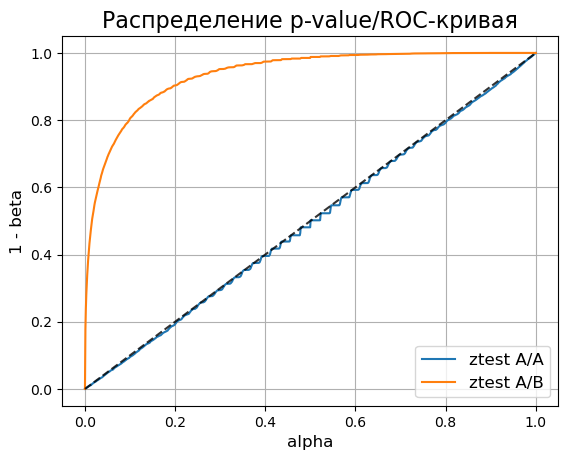

In [22]:
n_sim = 10**4
sample_size = 1000

dict_pvalues = defaultdict(list)
for _ in tqdm(range(n_sim)):

    x_control, x_treatment = stats.bernoulli(p_control).rvs(sample_size), stats.bernoulli(p_control * (1 + 0.2)).rvs(sample_size)

    z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment, alternative='larger')

    # сгенерируем ещё одну тестовую выборку, чтобы убедиться, что в случае когда выборки совпали,
    # наш тест работает корректно и не находит разницу
    x_control_again, _ = stats.bernoulli(p_control).rvs(sample_size), stats.bernoulli(p_control * (1 + 0)).rvs(sample_size)
    z_obs_aa, pval_aa = asy_mean_test(x_control, x_treatment, alternative='larger')

    x_control_again, _ = gen_sample(1000, 0, 0.2)
    z_obs_aa, pval_aa = asy_mean_test(x_control, x_control_again)

    dict_pvalues['ztest A/A'].append(pval_aa)
    dict_pvalues['ztest A/B'].append(pval_ab)

plot_pvalue_distribution(dict_pvalues)

Получившийся график можно проинтерпретировать двумя способами. Мы много-много раз проводим АБ-тест. В начале теста мы зафиксировали какую-то $\alpha$ и дальше проверяем кучу гипотез.

1. Линия `ztest A/A` это функция распределения pvalue при верности нулевой гипотезы. Оно было равномерным, мы двигаем $\alpha$ по оси $OX$ и оцениваем $\mathbb{P}(\text{pvalue} \le \alpha) = F(\alpha)$.  

По аналогии, линия `ztest A/B` это функция распределения pvalue при верности альтернативной гипотезы.

2. Линию `ztest A/B` можно проинтерпретировать как ROC-кривую. Если вы уже знаете про задачу классификации из машинного обучения, то это ровно оно. Полнота это $1 - \beta$, то есть то, сколько верных альтернативных гипотез мы найдём, если будем использовать наш АБ-тест, FPR это $\alpha$, то есть то, сколько верных нулевых гипотез мы заберём с собой в альтернативные. Эту величину мы определяем до старта эксперимента.

> Важно: если вы не поняли интерпретацию из пункта 2, просто забейте. Заботаете МО, поймёте. Интерпретацию из пункта 1 должны понять все. Если вы её не поняли, время напрячься и подумать ещё разок.

__Что для нас важно:__

- Чем выпуклее график, тем лучше мы находим эффект и процедура проверки гипотезы работае корректно;
- Чем больше у нас наблюдений тем выпуклее график;
- Чем сильнее в тестовой выборке подскакивает $p_t$ при изменениях, тем легче нам найти эффект и тем выпуклее график;
- Если $p_t$ подскочило на очень маленькую величину, нам сложнее найти это изменение, и график будет менее выпуклым;
- Чем меньше в выборках дисперсия, тем выпуклее график.

__е) [2 балла]__ При верности альтернативной гипотезы, постройте ROC-кривые из пункта выше для разного числа наблюдений в выборке: 10, 100, 1000, 10000 при любом фиксированном эффекте.

In [23]:
# Я решил переписать функцию plot_pvalue_distribution для построения большего, более понятного графика

  1%|          | 84/10000 [00:00<00:11, 833.87it/s]C:\Users\User\AppData\Local\Temp\ipykernel_2920\87024718.py:7: RuntimeWarning:

invalid value encountered in scalar divide

100%|██████████| 10000/10000 [00:14<00:00, 707.49it/s]


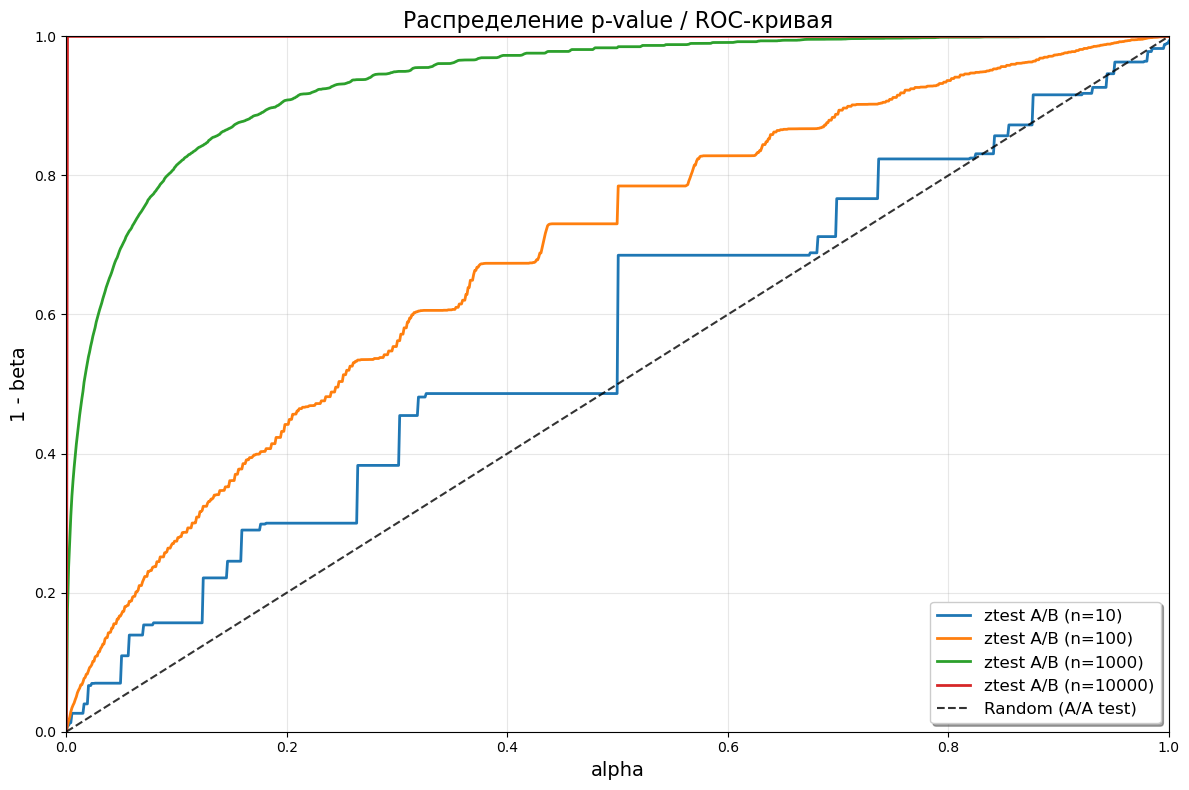

In [24]:
# в корректировке функции мне помог deepseek
def plot_pvalue_distribution(dict_pvalues):
    plt.figure(figsize=(12, 8))
    
    xseq = np.linspace(0, 1, 1000)

    for key, pvalues in dict_pvalues.items():
        yseq = [np.mean(np.array(pvalues) < x) for x in xseq]
        plt.plot(xseq, yseq, label=key, linewidth=2)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8, label='Random (A/A test)')
    plt.title('Распределение p-value / ROC-кривая', size=16)
    plt.xlabel('alpha', size=14)
    plt.ylabel('1 - beta', size=14)
    
 
    plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, shadow=True)
    
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

p_control = 0.2
n_sim = 10**4
dict_pvalues = defaultdict(list)

for sample_size in [10, 100, 1000, 10000]:    
    for _ in tqdm(range(n_sim)):
        x_control = stats.bernoulli(p_control).rvs(sample_size)
        x_treatment = stats.bernoulli(p_control * (1 + 0.2)).rvs(sample_size)

        z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment, alternative='larger')
        
        
        dict_pvalues[f'ztest A/B (n={sample_size})'].append(pval_ab)

plot_pvalue_distribution(dict_pvalues)


Ожидаемо, **чем больше наблюдений в выборке - тем больше площадь под ROC кривой**

__ё) [1 балл]__ Количество наблюдений, ошибка 1 и 2 рода, размер эффекта, который мы ищем и дисперсия в выборках связаны между собой. Для некоторых критериев проверки гипотез можно вывести формулы, которые их связывают.

В данном случае, формула для расчета числа наблюдений _для одной группы_ выглядит вот так:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

В приложении Яндекс.Такси в конце поездки вылезают рандомные опросники. В одном из опросников задаётся вопрос «А вы пристёгивались, когда ехали?»

В России, в день, в Такси происходит 1 миллион заказов. Вопрос про ремни задаётся рандомным 10% пользователей, закончивших поездку. Пользователь не игнорирует опросник и отвечает на него да или нет с вероятностью 5% (цифры взяты из головы и не отражают реальную статистику).

Менеджер Екатерина хочет сделать так, чтобы когда пассажир садится в машину, Алиса просила его пристегнуться. Хочется замерить, какой эффект это даст на пристёгивания. Станут ли люди чаще пристёгиваться. Замерять мы это будем опросником. Сейчас 10% пользователей говорят, что пристегнулись.

Екатерина пришла к вам и между вами состоялся следующий диалог:

- Хочу АБ-тест с разбивкой 50 на 50.
- Какие ошибки 1 и 2 рода хочешь?
- Нулевые.
- Нам надо бесконечно наблюдений, готова столько ждать?
- Нет.
- На сколько мы хотим, чтобы выросла доля ответов да?
- Если подрастёт хотябы на процент, будет круто.
- То есть если меньше процента, такой эффект считаем неудачей и отсутствием изменения?
- Да.
- Давай я нарисую тебе табличку с разными ошибками, а внутри на пересечении напишу сколько дней надо ждать, чтобы найти такой минимальный эффект.
- Давай, по ней и примем решение.

Нарисуйте для Екатерины такую табличку. Не забудьте перевести общее количество наблюдений в дни.

In [25]:
import scipy.stats as sts
import math

In [26]:
MDE = 0.01 # Екатерину устроит прирост на 1%

alphas = [0.01, 0.05, 0.1, 0.15]
betas = [0.1, 0.15, 0.2, 0.3]

In [27]:
# функция для вычисления необходимого количества дней для проведения АБ теста

def calculate_term(alpha, beta, p_contr=0.1, p_tr=0.11, MDE=0.01):

    sigma_control = p_contr * (1 - p_contr) # дисперсию считаю по формуле для биномиального распределения
    sigma_treatment = p_tr * (1 - p_tr)

    za = sts.norm.ppf(1 - alpha/2)
    zb = sts.norm.ppf(1 - beta)
    
    n1 = ((sigma_control + sigma_treatment) * (za + zb)**2) / (MDE**2) #необходимое число наблюдений для 1 группы
    n = n1 * 2 # так как нам нужно 2 группы - контрольная и тестовая

    days = math.ceil(n / 5000) # необходимое кол-во дней, так как в день ~10**6 * 0.1 * 0.05 пользователей, округляем в большую сторону, так как нам нужны полные дни

    return days

In [28]:
# функция создания датафрейма для необходимого количества дней для каждой комбинации (alpha, beta)

def create_table_for_Ekaterina(alphas_arr, betas_arr):
    days_arr = []
    for alpha in tqdm(alphas_arr):
        for beta in betas_arr:
            days_calculated = calculate_term(alpha, beta)  # вычисляю необходимое количество дней при фиксированных вероятностях ошибок 1 и 2 рода
            days_arr.append(days_calculated)
            
    multi_index = pd.MultiIndex.from_product([alphas, betas])
    series = pd.Series(days_arr, index=multi_index)
    table_for_Ekaterina = series.unstack()        #преобразовываю в датафрейм


    

    table_for_Ekaterina.index.name = 'alpha'
    table_for_Ekaterina.columns.name = 'beta'

    return table_for_Ekaterina


In [29]:
create_table_for_Ekaterina(alphas_arr=alphas, betas_arr=betas)

100%|██████████| 4/4 [00:00<00:00, 1001.45it/s]


beta,0.10,0.15,0.20,0.30
alpha,,,,
0.01,12,10,9,8
0.05,8,7,6,5
0.10,7,6,5,4
0.15,6,5,4,3


**Табличка выглядит реалистично.**\
С уменьшением alpha (увеличением строгости критерия) необходимое количество дней всегда растёт.\
С уменьшением beta (ростом мощности) необходимо количество дней так же всегда растёт.

__ж) [1 балл]__ Попробуем сломать наш АБ-тест. Когда мы используем z-тест, мы размышляем в терминах центральной предельной теоремы. Тест будет работать, если выполнены предпосылки ЦПТ:

- Наблюдения независимо одинаково распределены
- В данных нет выборосов, дисперсия конечная
- Данных много

Давайте сломаем одно из условий и попробуем собрать выборку из [распределения Парето](https://ru.wikipedia.org/wiki/Распределение_Парето).

In [30]:
def gen_sample(n_obs, b, effect):
    x_control = stats.pareto(b=b).rvs(n_obs)
    x_treatment = stats.pareto(b=b).rvs(n_obs)
    x_treatment = (1 + effect) * x_treatment
    return x_control, x_treatment

Отрисуйте ROC-кривые для $b=3$, $b=1$, $b=0.5$

100%|██████████| 3/3 [00:37<00:00, 12.64s/it]


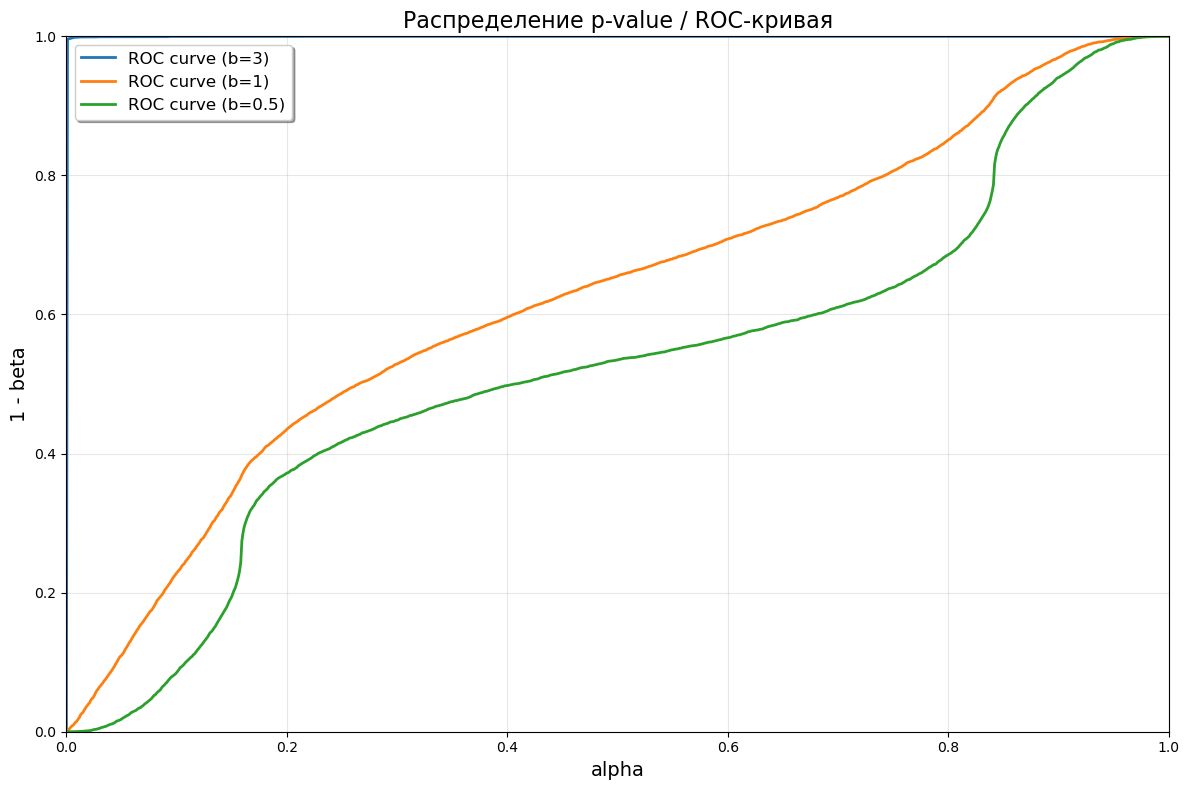

In [31]:
def plot_pvalue_distribution(dict_pvalues):
    plt.figure(figsize=(12, 8))
    
    xseq = np.linspace(0, 1, 1000)

    for key, pvalues in dict_pvalues.items():
        yseq = [np.mean(np.array(pvalues) < x) for x in xseq]
        plt.plot(xseq, yseq, label=key, linewidth=2)

    #plt.plot([0, 1], [0, 1], '--k', alpha=0.8, label='Random (A/A test)')
    plt.title('Распределение p-value / ROC-кривая', size=16)
    plt.xlabel('alpha', size=14)
    plt.ylabel('1 - beta', size=14)
    
 
    plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, shadow=True)
    
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

p_control = 0.2
n_sim = 10**4
dict_pvalues = defaultdict(list)
b_val = [3, 1, 0.5]
for sample_size in [1000]:
    for b in  tqdm(b_val):   
        for _ in tqdm(range(n_sim)):
            #x_control = stats.bernoulli(p_control).rvs(sample_size)
            #x_treatment = stats.bernoulli(p_control * (1 + 0.2)).rvs(sample_size)
            x_control, x_treatment = gen_sample(sample_size, b, effect = 0.2)
            z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment, alternative='larger')
        
        
            dict_pvalues[f'ROC curve (b={b})'].append(pval_ab)

plot_pvalue_distribution(dict_pvalues)

Распределение Парето имеет **конечное среднее при b > 1 и конечную дисперсию при b >2.**\
Соответственно, при b = 0.5 **условия ЦПТ критично нарушены**, поэтому площадь под кривой примерно 0.5, как при случайном угадывании.**Z-тест не работает.**\
При b = 1 **условия ЦПТ нарушены, Z-тест работает плохо** (лучше, чем при случайном угадывании, но не очень хорошо).\
При b=3 распределение имеет конечную дисперсию => **выполнены условия ЦПТ, Z-тест работает идеально**, площадь под кривой близка к 1 => высокая мощность


Возьмите при каждом $b$ одну выборку, нарисуйте для неё гистограмму и посмотрите как обстоят дела с выбросами.

In [32]:
# b = 0.5

x_control_b05, x_treatment_b05 = gen_sample(n_obs=1000, b=0.5, effect = 0.2)


In [33]:
#sns.histplot(data=x_control_b05, color='blue', alpha=0.5, kde=True, label='Распределение метрики в контрольной группе')
#sns.histplot(data=x_treatment_b05, color='orange', alpha=0.5, kde=True, label='Распределение метрики в тестовой группе')

#plt.xlabel('Метрика')
#plt.ylabel('Частота')
#plt.legend()

#plt.show()

График в ячейке выше не построился за разумное время из-за проблемы с бесконечной дисперсией у Парето распределения

In [ ]:
df_describe = pd.DataFrame(x_control_b05)
df_describe.columns = ['value']
df_describe.describe().round(3)

,value
count,1000.000
mean,528.468
std,4638.392
min,1.007
25%,1.761
50%,3.913
75%,16.271
max,104218.654


In [35]:
df_describe.columns

Index(['value'], dtype='object')

In [45]:
df_describe[df_describe['value'] > np.percentile(df_describe['value'], 97)].max()

value    104218.653858
dtype: float64

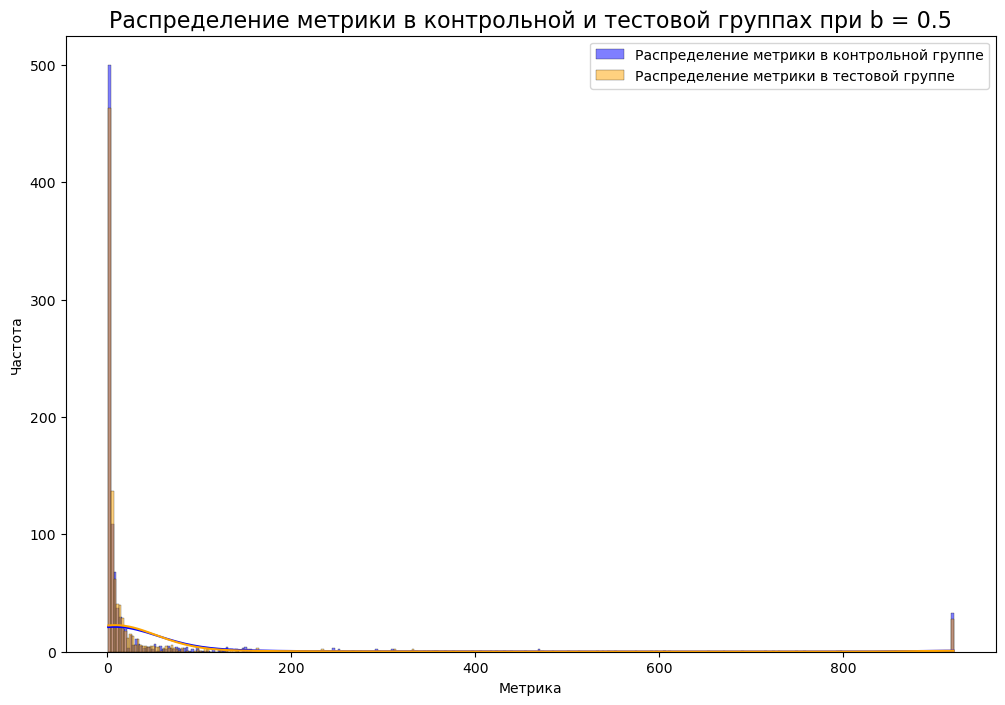

In [46]:
# Попробуем обрезать экстремальные значения (как я аметил выше, экстремальных значений очень мало, поэтому попробуем обрезать 97й перцентиль):
plt.figure(figsize=(12, 8))

clip_value = np.percentile(np.concatenate([x_control_b05, x_treatment_b05]), 97)
x_control_b05_clipped = np.clip(x_control_b05, 0, clip_value)
x_treatment_b05_clipped = np.clip(x_treatment_b05, 0, clip_value)

sns.histplot(data=x_control_b05_clipped, color='blue', alpha=0.5, kde=True, label='Распределение метрики в контрольной группе')
sns.histplot(data=x_treatment_b05_clipped, color='orange', alpha=0.5, kde=True, label='Распределение метрики в тестовой группе')

plt.xlabel('Метрика')
plt.ylabel('Частота')
plt.title('Распределение метрики в контрольной и тестовой группах при b = 0.5', size=16)

plt.legend()

plt.show()

Выбросы очень искажают распределение, так как они большие, даже при том, что я обрезал 97й перцентиль

In [47]:
# Теперь построим для b = 1

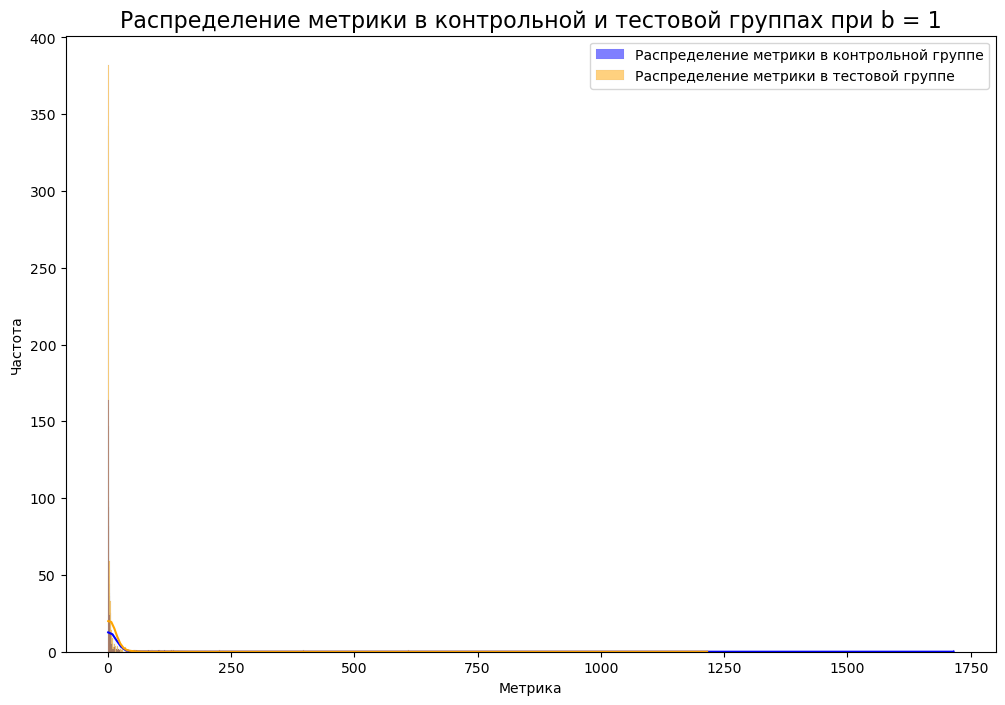

In [49]:
x_control_b1, x_treatment_b1 = gen_sample(n_obs=1000, b=1, effect = 0.2)

#clip_value = np.percentile(np.concatenate([x_control_b1, x_treatment_b1]), 97)
#x_control_b1_clipped = np.clip(x_control_b1, 0, clip_value)
#x_treatment_b1_clipped = np.clip(x_treatment_b1, 0, clip_value)


plt.figure(figsize=(12, 8))
sns.histplot(data=x_control_b1, color='blue', alpha=0.5, kde=True, label='Распределение метрики в контрольной группе')
sns.histplot(data=x_treatment_b1, color='orange', alpha=0.5, kde=True, label='Распределение метрики в тестовой группе')

plt.xlabel('Метрика')
plt.ylabel('Частота')
plt.title('Распределение метрики в контрольной и тестовой группах при b = 1', size=16)

plt.legend()

plt.show()

В такой визуализации из-за сильного влияния выбросов мало что понятно. Обрежем так же, по 97 перцентилю

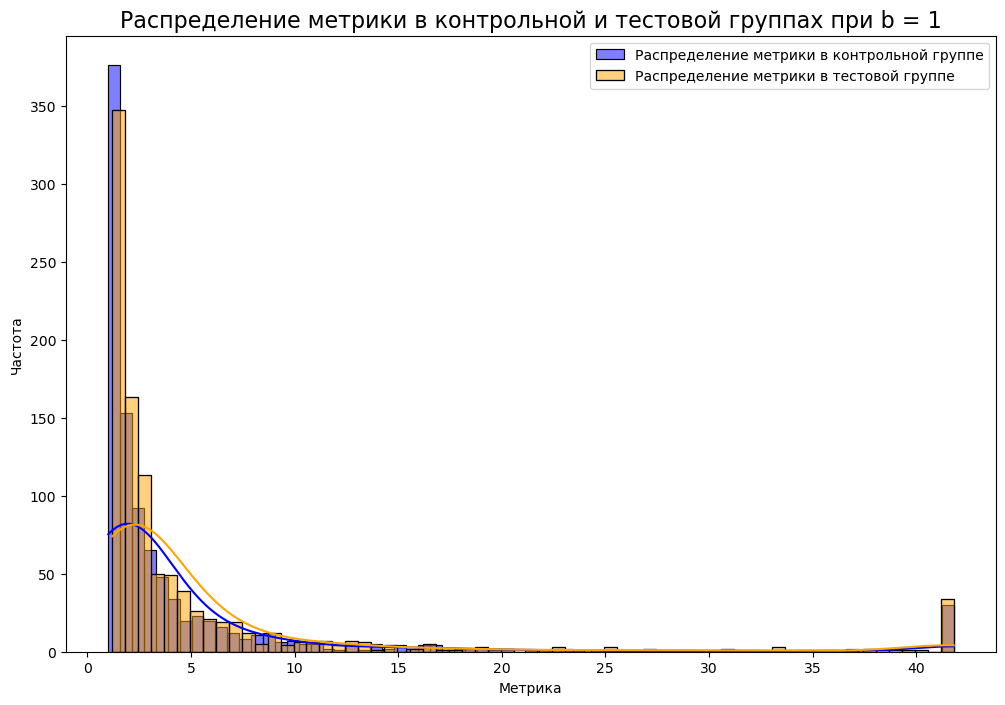

In [50]:
x_control_b1, x_treatment_b1 = gen_sample(n_obs=1000, b=1, effect = 0.2)

clip_value = np.percentile(np.concatenate([x_control_b1, x_treatment_b1]), 97)
x_control_b1_clipped = np.clip(x_control_b1, 0, clip_value)
x_treatment_b1_clipped = np.clip(x_treatment_b1, 0, clip_value)


plt.figure(figsize=(12, 8))
sns.histplot(data=x_control_b1_clipped, color='blue', alpha=0.5, kde=True, label='Распределение метрики в контрольной группе')
sns.histplot(data=x_treatment_b1_clipped, color='orange', alpha=0.5, kde=True, label='Распределение метрики в тестовой группе')

plt.xlabel('Метрика')
plt.ylabel('Частота')
plt.title('Распределение метрики в контрольной и тестовой группах при b = 1', size=16)

plt.legend()

plt.show()

Нетрудно заметить, что распределение в тестовой группе чуть сдвинуто вправо относительно распределения контрольной

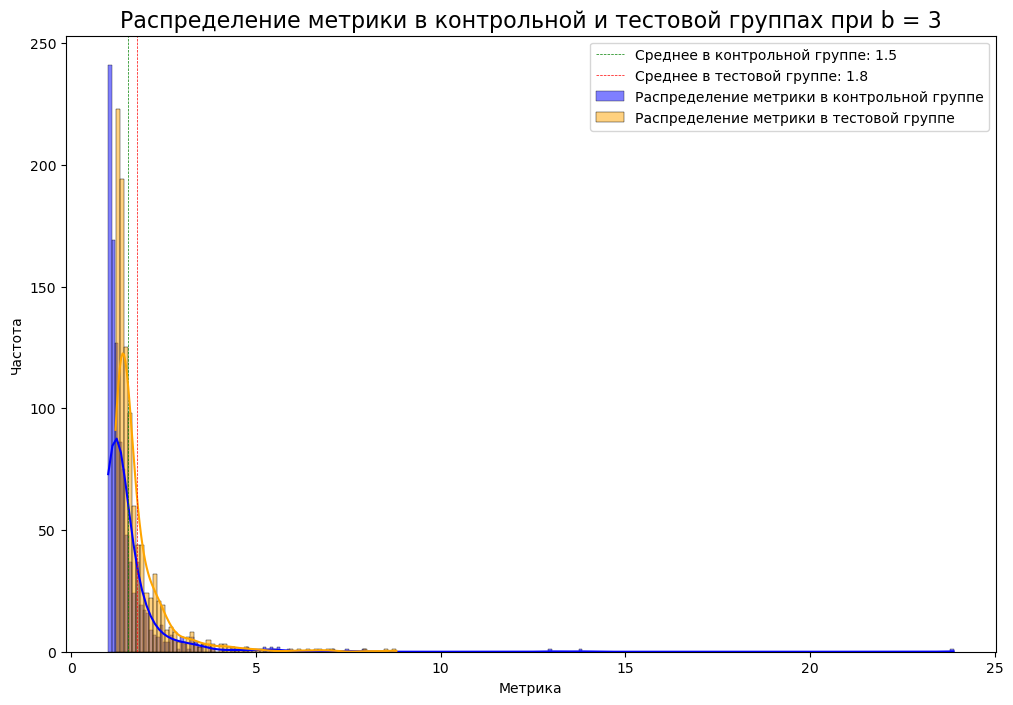

In [55]:
# Теперь построим для b = 3

x_control_b3, x_treatment_b3 = gen_sample(n_obs=1000, b=3, effect = 0.2)

#clip_value = np.percentile(np.concatenate([x_control_b1, x_treatment_b1]), 97)
#x_control_b1_clipped = np.clip(x_control_b1, 0, clip_value)
#x_treatment_b1_clipped = np.clip(x_treatment_b1, 0, clip_value)


plt.figure(figsize=(12, 8))
sns.histplot(data=x_control_b3, color='blue', alpha=0.5, kde=True, label='Распределение метрики в контрольной группе')
plt.axvline(x_control_b3.mean(), color='green', linestyle='--', linewidth=0.5, label=f'Среднее в контрольной группе: {x_control_b3.mean():.1f}')

sns.histplot(data=x_treatment_b3, color='orange', alpha=0.5, kde=True, label='Распределение метрики в тестовой группе')
plt.axvline(x_treatment_b3.mean(), color='red', linestyle='--', linewidth=0.5, label=f'Среднее в тестовой группе: {x_treatment_b3.mean():.1f}')

plt.xlabel('Метрика')
plt.ylabel('Частота')
plt.title('Распределение метрики в контрольной и тестовой группах при b = 3', size=16)

plt.legend()

plt.show()

Здесь даже не пришлось обрезать выбросы, так как при b = 3 **все предпосылки ЦПТ работают**.\
Чётко видно, что **распределение метрики в тестовой группе сдвинуто вправо относительно распределения контрольной**, что мы видим и по линиям средних.

У распределения Парето не всегда существует дисперсия. Это ломает предпосылки ЦПТ и АБ-тест разваливается.

Возникает вполне резонный вопрос: а что делать в таких ситуациях? Есть несколько дорог.

- Во-первых, можно отвязаться от математического ожидания и поработать с медианой. Для неё тоже можно вывести асимптотическое распределение с помощью дельта-метода.
- Во-вторых, можно попробовать другие техники проверки гипотез. Например, бутстрап и непараметрические критерии.

Об этом мы и будем говорить на следующих парах.